# 05a — Dimensionality Reduction (PCA + LDA)
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**This notebook investigates one methodological question:**

> Does projecting the ~6,200-dimensional feature vector to a lower-dimensional subspace using PCA or LDA improve, hurt, or leave classifier performance unchanged?

It answers RQ-supplementary: *"Is the curse of dimensionality real for this task?"*

### K-fold context

The main pipeline (notebooks 06, 07) uses 5-fold scene-aware cross-validation. This notebook uses **fold 0 as a representative fold** for dimensionality-reduction analysis, because:

1. This notebook uses fold 0 as a diagnostic fold to study dimensionality reduction behaviour. PCA and LDA results may vary across folds, especially because v1.0-mini has only 10 scenes, so the conclusions should be interpreted as representative diagnostics rather than final cross-validated evidence.
2. Running PCA/LDA across all 5 folds would 5× runtime with marginal new insight
3. Methodologically standard: report the analysis on one fold, note the representative choice in Limitations

If the user wishes to validate across folds, the same code applies — just change `REPRESENTATIVE_FOLD` from 0 to another value.

### Why this analysis matters

With **~6,200 features** and only **~325 training samples** per fold, the feature-to-sample ratio is **~19:1** — the curse of dimensionality is a real concern. We test whether dimensionality reduction helps.

### Two techniques compared

- **PCA** (Principal Component Analysis, Pearson 1901) — unsupervised, finds linear directions of maximum variance.
- **LDA** (Linear Discriminant Analysis, Fisher 1936) — supervised, finds linear directions of maximum class separability.

### Pipeline

```
Already-extracted features (~6,200 dims, from notebook 03)
        │
        ├── Raw                        → run classifier
        ├── PCA-projected (n_comp=k)   → run classifier
        └── LDA-projected (C-1 dims)   → run classifier per attribute
```

### Outputs

| File | Contents |
|---|---|
| `data/features/features_pca.csv` | PCA-projected features (fold 0 train+test, for reference) |
| `data/features/features_lda_<attr>.csv` | LDA-projected features per attribute |
| `data/features/dim_reduction_metadata.json` | Variance explained, component counts |
| `results/metrics/dim_reduction_metrics.csv` | Per-representation classifier metrics |
| `results/figures/dim_reduction/*.png` | Scree plot, 2D scatter, comparison bars |

### Companion notebook

- `05b_preprocessing_ablation.ipynb` — preprocessing ablation (histogram equalization, CLAHE)


## 0. Setup

In [5]:
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


In [6]:
def find_project_root():
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATASET_VERSION = 'v1.0-mini'
REPRESENTATIVE_FOLD = 0  # Use fold 0 as representative for dim-reduction analysis

PROCESSED_DIR = Path('data/processed') / DATASET_VERSION
LABEL_DIR    = PROCESSED_DIR / 'labels'
FEATURE_DIR  = PROCESSED_DIR / 'features'
SPLIT_DIR    = PROCESSED_DIR / 'splits'
RESULTS_DIR  = Path('results') / DATASET_VERSION / 'metrics'
FIG_DIR_DIM  = Path('results') / DATASET_VERSION / 'figures' / 'dim_reduction'
for p in [FEATURE_DIR, RESULTS_DIR, FIG_DIR_DIM]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
SEED_LIST = [42, 7, 123]
ATTRIBUTES = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']
CLASS_ORDERS = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}

print(f'PROJECT_ROOT    = {PROJECT_ROOT}')
print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'REPRESENTATIVE_FOLD = {REPRESENTATIVE_FOLD}')

PROJECT_ROOT    = C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml
DATASET_VERSION = v1.0-mini
REPRESENTATIVE_FOLD = 0


## 1. Load Fold-0 Train and Test Splits

In [7]:
df_train = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_train.csv')
df_test  = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_test.csv')

with open(FEATURE_DIR / 'feature_metadata.json') as f:
    feature_meta = json.load(f)
FEATURE_COLS = feature_meta['feature_columns_all']

print(f'Fold {REPRESENTATIVE_FOLD}:')
print(f'  train: {len(df_train)} samples')
print(f'  test:  {len(df_test)} samples')
print(f'  feature dimensions: {len(FEATURE_COLS)}')

Fold 0:
  train: 323 samples
  test:  81 samples
  feature dimensions: 6216


In [8]:
# Build matrices and standardise using train-fit scaler
X_train = df_train[FEATURE_COLS].values
X_test  = df_test[FEATURE_COLS].values

scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

print(f'Xs_train: {Xs_train.shape}   Xs_test: {Xs_test.shape}')

Xs_train: (323, 6216)   Xs_test: (81, 6216)


## 2. PCA — Variance Explained

We first determine how many components are needed to capture 90% / 95% / 99% of total variance.

In [9]:
pca_full = PCA(random_state=SEED)
pca_full.fit(Xs_train)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_for_90 = int(np.searchsorted(cumvar, 0.90)) + 1
n_for_95 = int(np.searchsorted(cumvar, 0.95)) + 1
n_for_99 = int(np.searchsorted(cumvar, 0.99)) + 1

print(f'Total components possible: {len(cumvar)}')
print(f'Components for 90% variance:  {n_for_90}')
print(f'Components for 95% variance:  {n_for_95}')
print(f'Components for 99% variance:  {n_for_99}')

Total components possible: 323
Components for 90% variance:  148
Components for 95% variance:  202
Components for 99% variance:  278


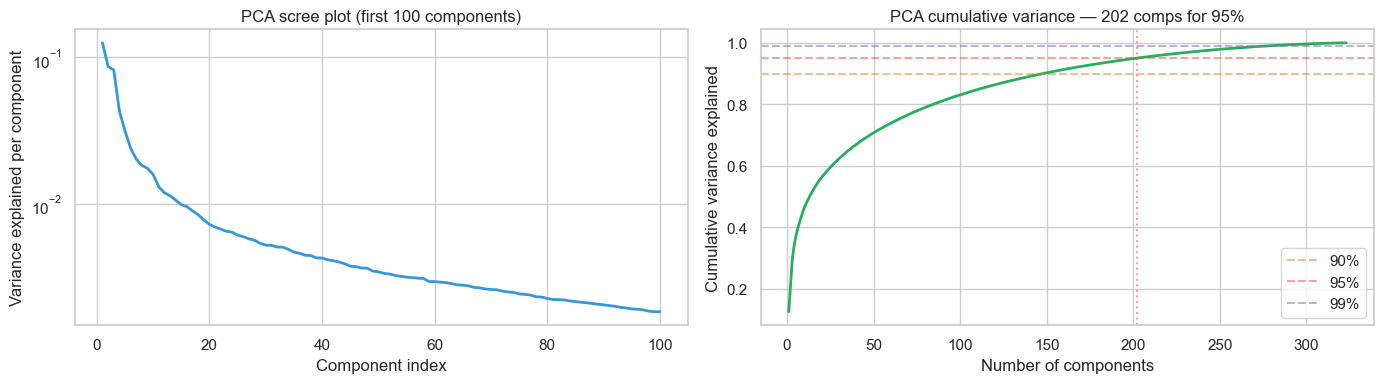

In [10]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
n_show = min(100, len(cumvar))

axes[0].plot(np.arange(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show],
             color='#3498db', linewidth=2)
axes[0].set_xlabel('Component index')
axes[0].set_ylabel('Variance explained per component')
axes[0].set_title('PCA scree plot (first 100 components)')
axes[0].set_yscale('log')

axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, color='#27ae60', linewidth=2)
axes[1].axhline(0.90, color='#e67e22', linestyle='--', alpha=0.5, label='90%')
axes[1].axhline(0.95, color='#e74c3c', linestyle='--', alpha=0.5, label='95%')
axes[1].axhline(0.99, color='#9b59b6', linestyle='--', alpha=0.5, label='99%')
axes[1].axvline(n_for_95, color='#e74c3c', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].set_title(f'PCA cumulative variance — {n_for_95} comps for 95%')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR_DIM / 'pca_scree.png', bbox_inches='tight')
plt.show()

## 3. PCA 2D Visualization

Visualizes class separability using only first 2 PCs — sanity check.

In [11]:
# Project full fold-0 dataset to 2D
all_features = np.vstack([Xs_train, Xs_test])
all_attr = pd.concat([df_train, df_test], ignore_index=True)

pca_2d = PCA(n_components=2, random_state=SEED).fit(Xs_train)
proj_2d = pca_2d.transform(all_features)

print(f'Full fold-0 set projected to 2D: {proj_2d.shape}')
print(f'Variance captured by first 2 PCs: {pca_2d.explained_variance_ratio_.sum():.3f}')

Full fold-0 set projected to 2D: (404, 2)
Variance captured by first 2 PCs: 0.212


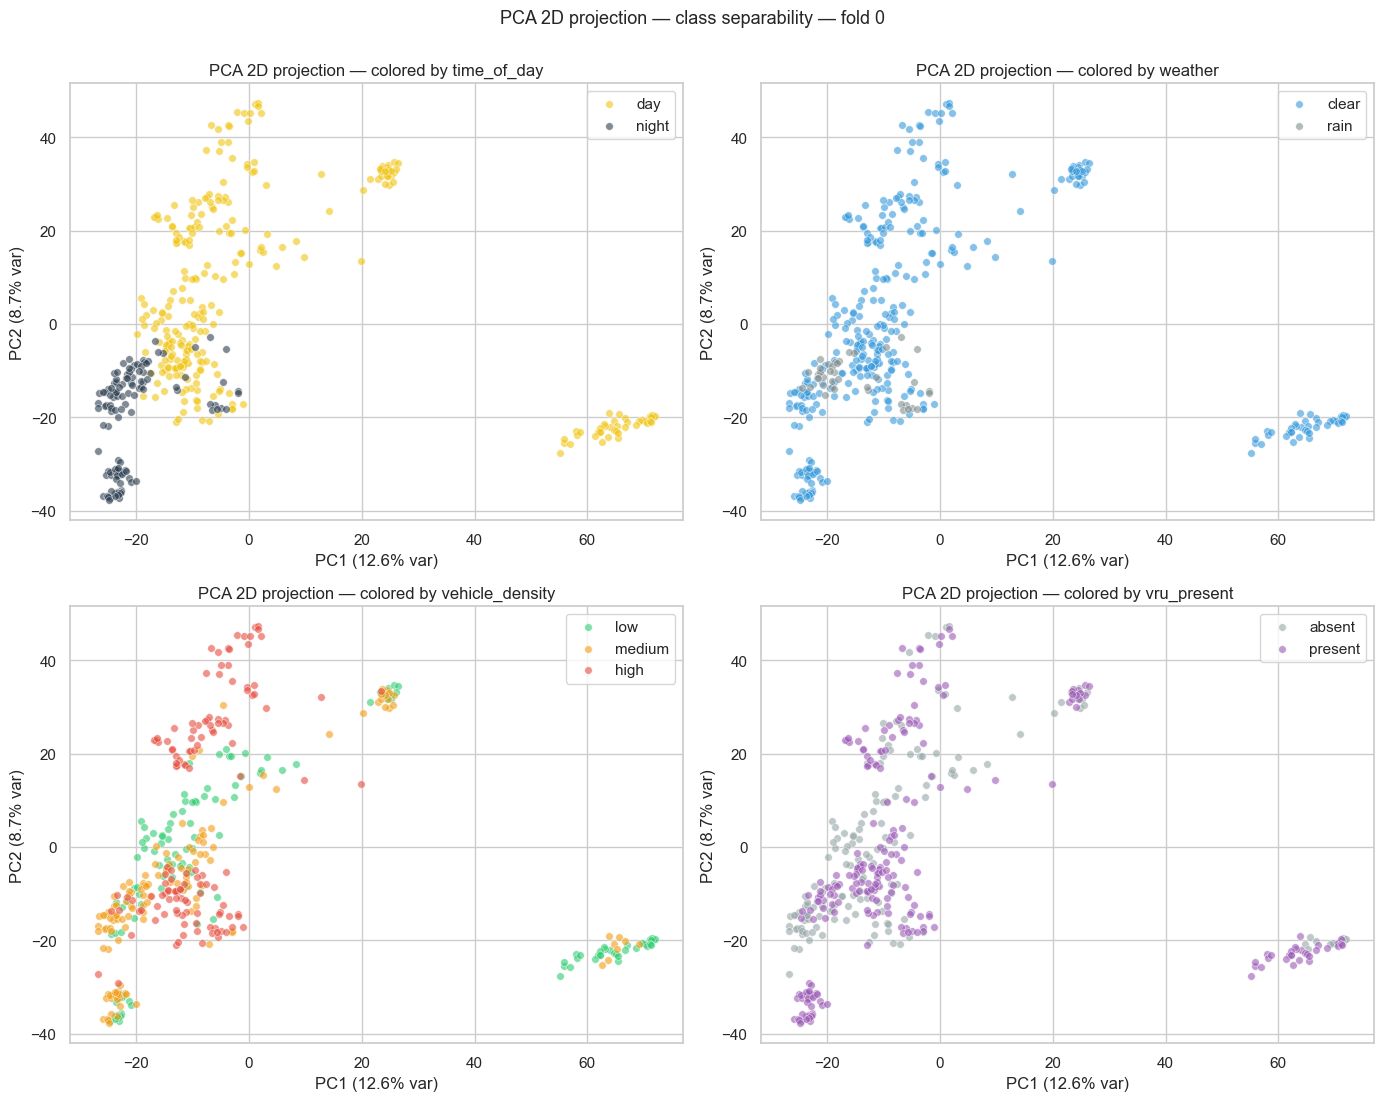

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
attr_colors = {
    'time_of_day':     {'day': '#f1c40f', 'night': '#2c3e50'},
    'weather':         {'clear': '#3498db', 'rain': '#7f8c8d'},
    'vehicle_density': {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'},
    'vru_present':     {'absent': '#95a5a6', 'present': '#9b59b6'},
}

for ax, attr in zip(axes.flatten(), ATTRIBUTES):
    for cls in CLASS_ORDERS[attr]:
        mask = (all_attr[attr] == cls).values
        if mask.sum() == 0: continue
        ax.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
                   c=attr_colors[attr][cls], label=cls,
                   s=30, alpha=0.6, edgecolor='white', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)')
    ax.set_title(f'PCA 2D projection — colored by {attr}')
    ax.legend(loc='best')

plt.suptitle(f'PCA 2D projection — class separability — fold {REPRESENTATIVE_FOLD}',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR_DIM / 'pca_2d_by_attribute.png', bbox_inches='tight')
plt.show()

## 4. LDA — Supervised Projection Per Attribute

LDA finds projections that maximize class separability. Limited to C-1 components.

In [13]:
lda_models = {}
lda_train  = {}
lda_test   = {}

for attr in ATTRIBUTES:
    le = LabelEncoder().fit(CLASS_ORDERS[attr])
    y_tr = le.transform(df_train[attr].values)

    n_unique_train = len(np.unique(y_tr))
    if n_unique_train < 2:
        print(f'{attr:18s}: SKIP — train has {n_unique_train} class(es), need >=2 for LDA')
        continue

    n_comp = min(n_unique_train - 1, Xs_train.shape[1])
    lda = LinearDiscriminantAnalysis(n_components=n_comp)
    lda.fit(Xs_train, y_tr)

    lda_models[attr] = lda
    lda_train[attr]  = lda.transform(Xs_train)
    lda_test[attr]   = lda.transform(Xs_test)

    print(f'{attr:18s}: {n_comp} components — train shape {lda_train[attr].shape}')

time_of_day       : 1 components — train shape (323, 1)
weather           : SKIP — train has 1 class(es), need >=2 for LDA
vehicle_density   : 2 components — train shape (323, 2)
vru_present       : 1 components — train shape (323, 1)


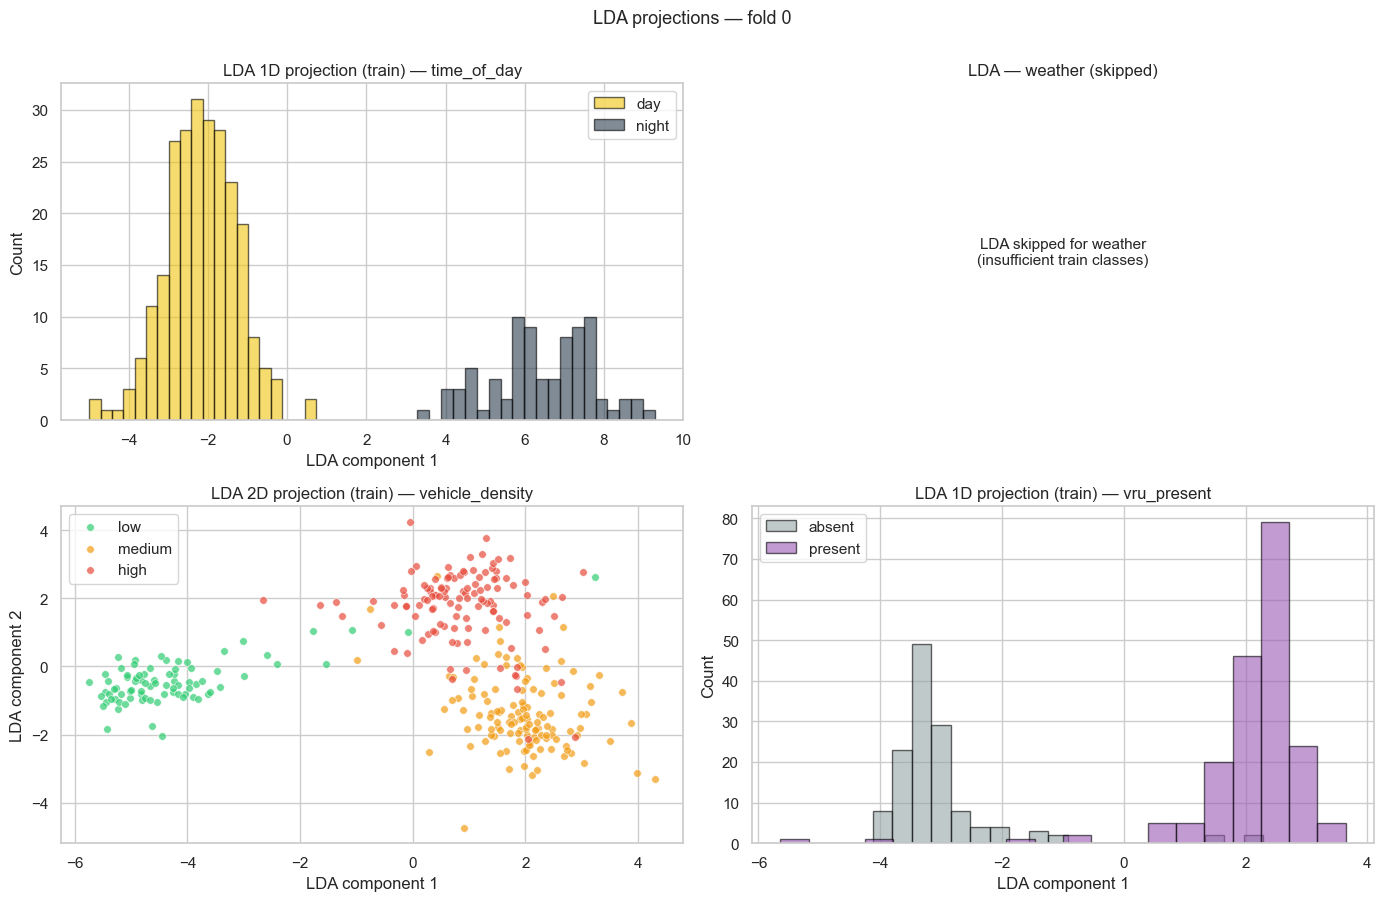

In [14]:
# Visualise LDA projection
n_attrs = len(lda_train)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, attr in zip(axes.flatten(), ATTRIBUTES):
    if attr not in lda_train:
        ax.text(0.5, 0.5, f'LDA skipped for {attr}\n(insufficient train classes)',
                ha='center', va='center', fontsize=11)
        ax.set_title(f'LDA — {attr} (skipped)')
        ax.axis('off')
        continue

    le = LabelEncoder().fit(CLASS_ORDERS[attr])
    y_tr = le.transform(df_train[attr].values)
    proj = lda_train[attr]

    if proj.shape[1] == 1:
        for i, cls in enumerate(CLASS_ORDERS[attr]):
            mask = (y_tr == i)
            if mask.sum() == 0: continue
            ax.hist(proj[mask, 0], bins=20, alpha=0.6,
                    label=cls, color=attr_colors[attr][cls],
                    edgecolor='black')
        ax.set_xlabel('LDA component 1')
        ax.set_ylabel('Count')
        ax.set_title(f'LDA 1D projection (train) — {attr}')
        ax.legend()
    else:
        for i, cls in enumerate(CLASS_ORDERS[attr]):
            mask = (y_tr == i)
            if mask.sum() == 0: continue
            ax.scatter(proj[mask, 0], proj[mask, 1],
                       c=attr_colors[attr][cls], label=cls,
                       s=30, alpha=0.7, edgecolor='white', linewidth=0.5)
        ax.set_xlabel('LDA component 1')
        ax.set_ylabel('LDA component 2')
        ax.set_title(f'LDA 2D projection (train) — {attr}')
        ax.legend()

plt.suptitle(f'LDA projections — fold {REPRESENTATIVE_FOLD}',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR_DIM / 'lda_projections.png', bbox_inches='tight')
plt.show()

## 5. Classifier Comparison — Raw vs PCA vs LDA

For each (attribute, representation), train Logistic Regression and Random Forest with class-weighted training. Multi-seed runs (3 seeds) for stability.

In [15]:
PCA_N_COMP = n_for_95
print(f'Using PCA n_components = {PCA_N_COMP} (95% variance)')

pca_chosen = PCA(n_components=PCA_N_COMP, random_state=SEED).fit(Xs_train)
pca_train = pca_chosen.transform(Xs_train)
pca_test  = pca_chosen.transform(Xs_test)

print(f'PCA-projected — train: {pca_train.shape}  test: {pca_test.shape}')

Using PCA n_components = 202 (95% variance)
PCA-projected — train: (323, 202)  test: (81, 202)


In [16]:
def fit_eval(model, X_tr, X_te, y_tr, y_te):
    """Fit, predict, return test metrics."""
    if len(np.unique(y_tr)) < 2:
        return None  # cannot fit single-class
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    yp = model.predict(X_te)
    return {
        'accuracy':  accuracy_score(y_te, yp),
        'macro_f1':  f1_score(y_te, yp, average='macro', zero_division=0),
        'fit_time':  fit_time,
    }

def make_lr(seed):
    return LogisticRegression(class_weight='balanced', max_iter=2000, random_state=seed)

def make_rf(seed):
    return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   random_state=seed, n_jobs=-1)

print('Helpers ready.')

Helpers ready.


In [17]:
dim_results = []

for attr in ATTRIBUTES:
    le = LabelEncoder().fit(CLASS_ORDERS[attr])
    y_tr = le.transform(df_train[attr].values)
    y_te = le.transform(df_test[attr].values)

    # Skip attribute if train has <2 classes
    if len(np.unique(y_tr)) < 2:
        print(f'⚠️  SKIP {attr}: train has {len(np.unique(y_tr))} classes')
        continue

    representations = {
        'raw':  (Xs_train, Xs_test),
        'pca':  (pca_train, pca_test),
    }
    if attr in lda_train:
        representations['lda'] = (lda_train[attr], lda_test[attr])

    for rep_name, (X_tr_rep, X_te_rep) in representations.items():
        for seed in SEED_LIST:
            for model_name, model_factory in [('LogReg', make_lr), ('RandomForest', make_rf)]:
                m = fit_eval(model_factory(seed), X_tr_rep, X_te_rep, y_tr, y_te)
                if m is None: continue
                m.update({
                    'attribute': attr, 'representation': rep_name,
                    'model': model_name, 'seed': seed,
                    'n_features': X_tr_rep.shape[1],
                    'fold': REPRESENTATIVE_FOLD,
                })
                dim_results.append(m)

df_dim = pd.DataFrame(dim_results)
df_dim.to_csv(RESULTS_DIR / 'dim_reduction_metrics.csv', index=False)
print(f'Dim reduction results: {len(df_dim)} rows')
print(f'Saved → {RESULTS_DIR / "dim_reduction_metrics.csv"}')

⚠️  SKIP weather: train has 1 classes
Dim reduction results: 54 rows
Saved → results\v1.0-mini\metrics\dim_reduction_metrics.csv


## 6. Summary

In [18]:
summary = (df_dim.groupby(['attribute', 'representation', 'model'])
                  [['accuracy', 'macro_f1', 'n_features']]
                  .agg(['mean', 'std']).round(3))
print('Test-set performance — Raw vs PCA vs LDA (fold 0):')
display(summary)

Test-set performance — Raw vs PCA vs LDA (fold 0):


accuracy        macro_f1         \
                                                mean    std     mean    std   
attribute       representation model                                          
time_of_day     lda            LogReg          0.840  0.000    0.835  0.000   
                               RandomForest    0.815  0.000    0.807  0.000   
                pca            LogReg          0.790  0.000    0.784  0.000   
                               RandomForest    0.675  0.007    0.633  0.010   
                raw            LogReg          0.679  0.000    0.678  0.000   
                               RandomForest    0.807  0.014    0.798  0.016   
vehicle_density lda            LogReg          0.309  0.000    0.318  0.000   
                               RandomForest    0.272  0.000    0.294  0.000   
                pca            LogReg          0.185  0.000    0.191  0.000   
                               RandomForest    0.156  0.029    0.197  0.044   
                raw            LogReg          0.259  0.000    0.316  0.000   
                               RandomForest    0.193  0.026    0.160  0.042   
vru_present     lda            LogReg          0.358  0.000    0.328  0.000   
                               RandomForest    0.432  0.000    0.335  0.000   
                pca            LogReg          0.346  0.000    0.303  0.000   
                               RandomForest    0.379  0.007    0.290  0.004   
                raw            LogReg          0.395  0.000    0.381  0.000   
                               RandomForest    0.395  0.025    0.294  0.030   

                                            n_features       
                                                  mean  std  
attribute       representation model                         
time_of_day     lda            LogReg              1.0  0.0  
                               RandomForest        1.0  0.0  
                pca            LogReg            202.0  0.0  
                               RandomForest      202.0  0.0  
                raw            LogReg           6216.0  0.0  
                               RandomForest     6216.0  0.0  
vehicle_density lda            LogReg              2.0  0.0  
                               RandomForest        2.0  0.0  
                pca            LogReg            202.0  0.0  
                               RandomForest      202.0  0.0  
                raw            LogReg           6216.0  0.0  
                               RandomForest     6216.0  0.0  
vru_present     lda            LogReg              1.0  0.0  
                               RandomForest        1.0  0.0  
                pca            LogReg            202.0  0.0  
                               RandomForest      202.0  0.0  
                raw            LogReg           6216.0  0.0  
                               RandomForest     6216.0  0.0

In [19]:
pivot = (df_dim.groupby(['attribute', 'representation'])['macro_f1']
                .mean().round(3).unstack('representation'))

# Order columns sensibly
col_order = [c for c in ['raw', 'pca', 'lda'] if c in pivot.columns]
pivot = pivot[col_order].reindex(ATTRIBUTES)

print(f'Mean test macro-F1 (averaged across LogReg + RF, 3 seeds):')
print(f'  Fold {REPRESENTATIVE_FOLD} only')
display(pivot)

Mean test macro-F1 (averaged across LogReg + RF, 3 seeds):
  Fold 0 only


representation,raw,pca,lda
attribute,,,
time_of_day,0.738,0.708,0.821
weather,NaN,NaN,NaN
vehicle_density,0.238,0.194,0.306
vru_present,0.338,0.296,0.332


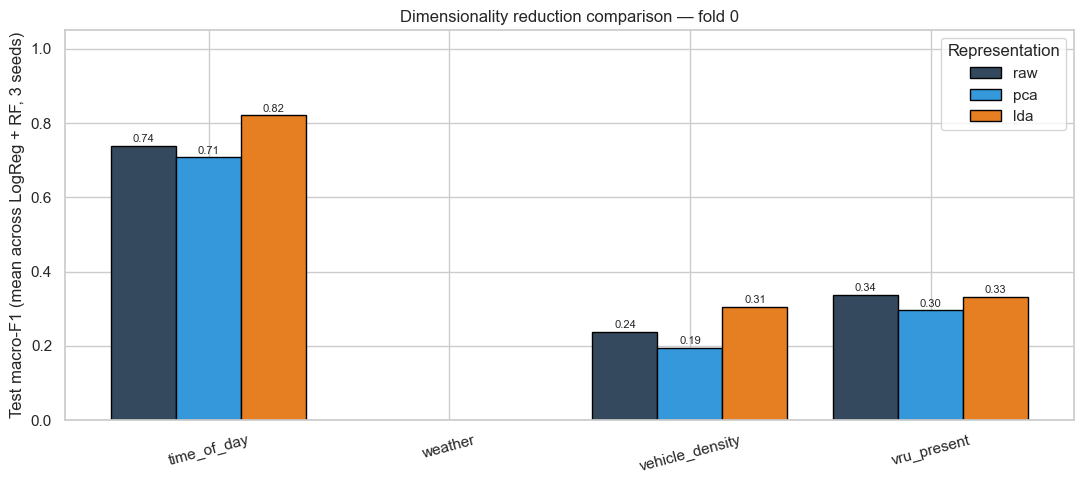

In [20]:
# Bar comparison
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ATTRIBUTES))
w = 0.27
colors = {'raw': '#34495e', 'pca': '#3498db', 'lda': '#e67e22'}

for i, rep in enumerate(col_order):
    vals = pivot[rep].values
    ax.bar(x + (i - 1) * w, vals, w, label=rep, color=colors.get(rep, 'gray'),
            edgecolor='black')
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(j + (i - 1) * w, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(ATTRIBUTES, rotation=15)
ax.set_ylabel('Test macro-F1 (mean across LogReg + RF, 3 seeds)')
ax.set_title(f'Dimensionality reduction comparison — fold {REPRESENTATIVE_FOLD}')
ax.set_ylim(0, 1.05)
ax.legend(title='Representation')
plt.tight_layout()
plt.savefig(FIG_DIR_DIM / 'dim_reduction_comparison.png', bbox_inches='tight')
plt.show()

## 7. Save Projections for Reference

In [21]:
# PCA projections — single CSV
pca_columns = [f'pca_{i}' for i in range(PCA_N_COMP)]
df_pca = pd.DataFrame(np.vstack([pca_train, pca_test]), columns=pca_columns)
df_pca.insert(0, 'sample_token',
               pd.concat([df_train['sample_token'], df_test['sample_token']],
                          ignore_index=True).values)
df_pca['split'] = ['train'] * len(df_train) + ['test'] * len(df_test)
df_pca['fold'] = REPRESENTATIVE_FOLD
df_pca.to_csv(FEATURE_DIR / 'features_pca.csv', index=False)
print(f'Saved → features_pca.csv ({df_pca.shape})')

Saved → features_pca.csv ((404, 205))


In [22]:
# LDA projections — one CSV per attribute
for attr in ATTRIBUTES:
    if attr not in lda_train: continue
    n_comp = lda_train[attr].shape[1]
    lda_cols = [f'lda_{attr}_{i}' for i in range(n_comp)]
    df_l = pd.DataFrame(np.vstack([lda_train[attr], lda_test[attr]]),
                         columns=lda_cols)
    df_l.insert(0, 'sample_token',
                 pd.concat([df_train['sample_token'], df_test['sample_token']],
                            ignore_index=True).values)
    df_l['split'] = ['train'] * len(df_train) + ['test'] * len(df_test)
    df_l['fold'] = REPRESENTATIVE_FOLD
    df_l.to_csv(FEATURE_DIR / f'features_lda_{attr}.csv', index=False)
    print(f'Saved → features_lda_{attr}.csv ({df_l.shape})')

Saved → features_lda_time_of_day.csv ((404, 4))
Saved → features_lda_vehicle_density.csv ((404, 5))
Saved → features_lda_vru_present.csv ((404, 4))


In [23]:
# Save metadata
dim_meta = {
    'dataset_version': DATASET_VERSION,
    'representative_fold': REPRESENTATIVE_FOLD,
    'pca_n_components': int(PCA_N_COMP),
    'pca_variance_explained': float(cumvar[PCA_N_COMP - 1]),
    'lda_n_components_per_attribute': {
        a: int(lda_train[a].shape[1]) for a in ATTRIBUTES if a in lda_train
    },
    'reference_n_features_raw': int(Xs_train.shape[1]),
    'note': (
        'PCA / LDA analysis was performed on fold 0 as a representative diagnostic fold. '
        'Because v1.0-mini contains only 10 scenes, PCA and LDA behaviour may vary across folds, '
        'especially for rare classes such as rain. These projections should be interpreted as '
        'fold-0 reference projections, not globally valid representations for all folds.'
    ),
}
with open(FEATURE_DIR / 'dim_reduction_metadata.json', 'w') as f:
    json.dump(dim_meta, f, indent=2)
print('Saved → dim_reduction_metadata.json')
print(json.dumps(dim_meta, indent=2))

Saved → dim_reduction_metadata.json
{
  "dataset_version": "v1.0-mini",
  "representative_fold": 0,
  "pca_n_components": 202,
  "pca_variance_explained": 0.9502891891775032,
  "lda_n_components_per_attribute": {
    "time_of_day": 1,
    "vehicle_density": 2,
    "vru_present": 1
  },
  "reference_n_features_raw": 6216,
  "note": "PCA / LDA analysis was performed on fold 0 as a representative diagnostic fold. Because v1.0-mini contains only 10 scenes, PCA and LDA behaviour may vary across folds, especially for rare classes such as rain. These projections should be interpreted as fold-0 reference projections, not globally valid representations for all folds."
}


---
## Findings & Decisions

**PCA variance analysis**
- The raw hand-crafted feature vector contains 6,216 dimensions.
- PCA required 148 components to capture 90% variance, 202 components to capture 95% variance, and 278 components to capture 99% variance on the fold-0 training set.
- Using 202 PCA components for 95% variance reduces the feature dimensionality from 6,216 to 202, a reduction of approximately 30.8×.
- The first two principal components captured approximately 21.2% of the variance, so 2D PCA plots are useful only as visual diagnostics, not as evidence of full separability.

**LDA analysis**
- LDA produced 1 component for `time_of_day`, 2 components for `vehicle_density`, and 1 component for `vru_present`.
- `weather` was skipped for LDA and classifier comparison in fold 0 because the fold-0 training set contains only one weather class.
- This confirms that the rain class in v1.0-mini is too scene-concentrated for reliable fold-level weather analysis.

**Classifier comparison on fold 0**
- Raw, PCA, and LDA representations were compared using Logistic Regression and Random Forest across three random seeds.
- For `time_of_day`, LDA achieved the strongest average macro-F1 among the tested representations.
- For `vehicle_density`, LDA also improved over raw and PCA features in the fold-0 diagnostic comparison.
- For `vru_present`, raw features and LDA were similar, while PCA was weaker.
- These results should be interpreted as a diagnostic comparison on fold 0, not as the final model-evaluation result.

**Decision for downstream pipeline**
- The main modelling notebooks should continue using raw standardised features as the primary representation.
- PCA and LDA results should be reported as a complementary dimensionality-reduction study.
- PCA may be useful for reducing dimensionality, but it can remove discriminative information because it is unsupervised.
- LDA can improve separability for some attributes, but it is supervised and must be fitted inside each training fold to avoid leakage.

**Limitations**
- This notebook uses fold 0 only, so results may vary across the other scene-aware folds.
- `weather` cannot be evaluated in fold 0 because the training split contains only one weather class.
- PCA and LDA projections saved by this notebook are fold-0 reference projections and should not be treated as globally valid representations for all folds.
- The v1.0-mini split has only 10 scenes, so dimensionality-reduction findings are best interpreted as methodological diagnostics.

**Implications for the report**
- The PCA result supports the argument that the 6,216-dimensional feature vector is high-dimensional relative to the number of training samples.
- The LDA result shows that supervised projections can improve apparent class separation for some attributes.
- The final model comparison should still rely on full scene-aware cross-validation rather than this fold-0 diagnostic alone.